In [1]:
import sys
sys.path.append('../../../../../')
%matplotlib inline

In [2]:
from CADETProcess.processModel import ComponentSystem, LumpedRateModelWithPores, Linear
from CADETProcess.instruments import LCFlowSheet

cs = ComponentSystem(["Salt", "Protein"])
Q = 1.0e-8  # m³/s

fs = LCFlowSheet(
    cs,
    sample_loop_volume=50e-9,
    sample_loop_diameter=0.75e-3,
    ColumnModel=LumpedRateModelWithPores,
    BindingModel=Linear,
)
print("units:", [u.name for u in fs.units])

units: ['buffer_a', 'buffer_b', 'buffer_c', 'buffer_d', 'feed_inlet', 'mixer', 'tubing_pre_injection', 'sample_loop', 'tubing_pre_column', 'column', 'tubing_post_column', 'tubing_detectors', 'outlet', 'waste']


In [3]:
fs_no_col = LCFlowSheet(
    cs,
    sample_loop_volume=50e-9,
    sample_loop_diameter=0.75e-3,
    bypass_units=["tubing_pre_column", "column", "tubing_post_column", "tubing_detectors"],
)
print("units:", [u.name for u in fs_no_col.units])

units: ['buffer_a', 'buffer_b', 'buffer_c', 'buffer_d', 'feed_inlet', 'mixer', 'tubing_pre_injection', 'sample_loop', 'outlet', 'waste']


In [4]:
from CADETProcess.instruments import Phase

gradient = Phase(400.0, Q, {"A": 1.0}, {"B": 1.0})  # A → 0, B → 1 over 400 s
wash     = Phase(200.0, Q, {"A": 1.0})              # step: constant 100 % A
feed     = Phase(60.0,  Q, {"F": 1.0})              # sample via feed inlet
print("gradient end:", gradient.composition_end, "| wash end:", wash.composition_end)

gradient end: {'B': 1.0} | wash end: {'A': 1.0}


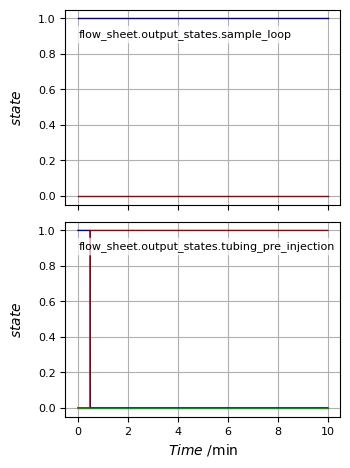

In [5]:
from CADETProcess.instruments import LCProcess

single = LCProcess("single_inj", fs_no_col)
single.cycle_time = 600.0
single.add_valve_event("inject", t=0.0)
single.add_valve_event("run",    t=30.0)
single.plot_events();

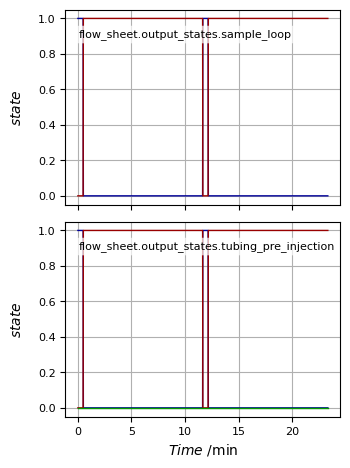

In [6]:
multi = LCProcess("multi_inj", fs_no_col)
multi.cycle_time = 1400.0
multi.add_valve_event("inject", t=0.0)    # first injection: loop → flow path
multi.add_valve_event("load",   t=30.0)   # feed_inlet refills the loop during the run
multi.add_valve_event("inject", t=700.0)  # second injection
multi.add_valve_event("load",   t=730.0)  # reload again
multi.plot_events();

cycle_time: 700.0 s
events: ['phase_0_A', 'phase_0_B', 'phase_1_A', 'phase_1_B', 'phase_2_A', 'phase_2_B']


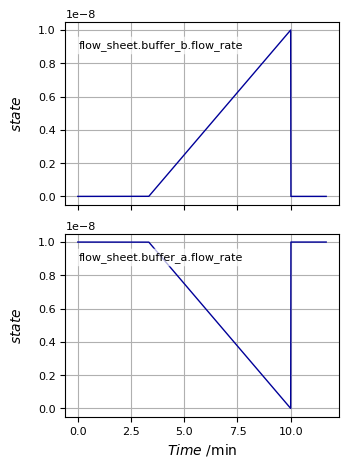

In [7]:
from CADETProcess.instruments import PhasedProcess

steps = [
    Phase(200.0, Q, {"A": 1.0}),                 # wash: 100 % A
    Phase(400.0, Q, {"A": 1.0}, {"B": 1.0}),     # gradient: A → 0, B → 1
    Phase(100.0, Q, {"A": 1.0}),                 # final wash
]
custom = PhasedProcess("custom", fs_no_col, steps)
print("cycle_time:", custom.cycle_time, "s")
print("events:", [e.name for e in custom.events])
custom.plot_events();

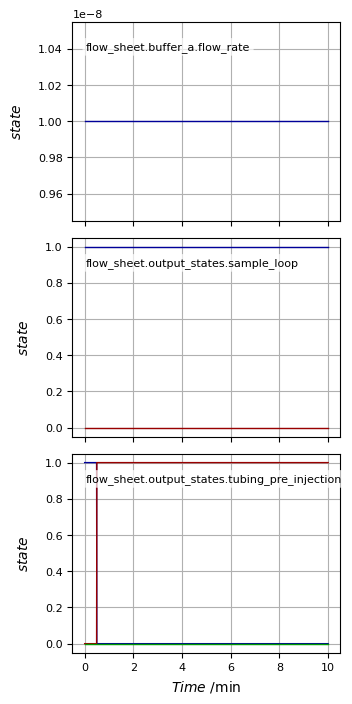

In [8]:
from CADETProcess.instruments import ValveEvent

pulse_steps = [
    ValveEvent("inject"),
    Phase(30.0,  Q, {"A": 1.0}),
    ValveEvent("run"),
    Phase(570.0, Q, {"A": 1.0}),
]
pulse_proc = PhasedProcess("pulse", fs_no_col, pulse_steps)
pulse_proc.plot_events();

cycle_time: 600.0 s
buffer_a flow rate: 1e-08 m³/s


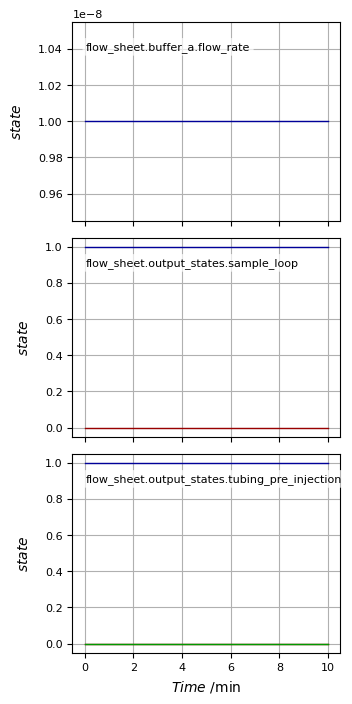

In [9]:
from CADETProcess.instruments import PulseInjection

pulse = PulseInjection(
    "pulse", fs_no_col,
    c_buffer_a=[0.0, 0.0],
    c_sample=[0.0, 1.0],
    cycle_time=600.0,
    flow_rate=Q,
)
print("cycle_time:", pulse.cycle_time, "s")
print("buffer_a flow rate:", pulse.flow_sheet.buffer_a.flow_rate[0], "m³/s")
pulse.plot_events();

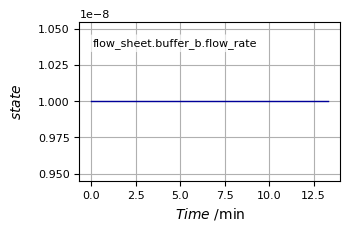

In [10]:
from CADETProcess.instruments import Step

step = Step(
    "step", fs_no_col,
    c_buffer_a=[0.0, 0.0],
    c_buffer_b=[1000.0, 0.0],
    cycle_time=800.0,
    flow_rate=Q,
)
step.plot_events();

cycle_time: 700.0 s


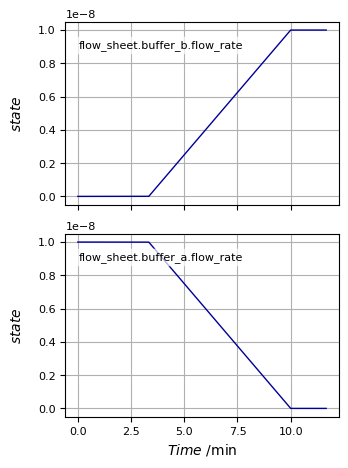

In [11]:
from CADETProcess.instruments import LWE

lwe = LWE(
    "lwe", fs,
    c_buffer_a=[20.0, 0.0],
    c_buffer_b=[1000.0, 0.0],
    c_sample=[20.0, 1.0],
    delta_t_wash=200.0,
    delta_t_elute=400.0,
    delta_t_final_wash=100.0,
    flow_rate_wash=Q,
)
print("cycle_time:", lwe.cycle_time, "s")
lwe.plot_events();

cycle_time: 700.0 s


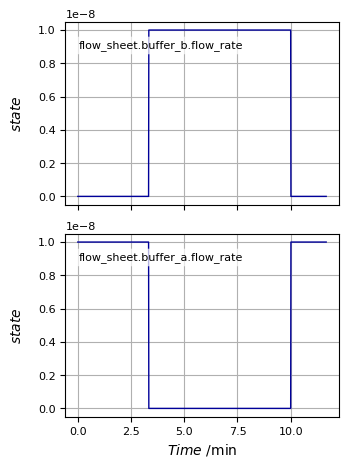

In [12]:
from CADETProcess.instruments import StepElution

se = StepElution(
    "se", fs,
    c_buffer_a=[20.0, 0.0],
    c_buffer_b=[1000.0, 0.0],
    c_sample=[20.0, 1.0],
    delta_t_wash=200.0,
    delta_t_elute=400.0,
    delta_t_final_wash=100.0,
    flow_rate_wash=Q,
)
print("cycle_time:", se.cycle_time, "s")
se.plot_events();

feed flow rate: 1e-08 m³/s


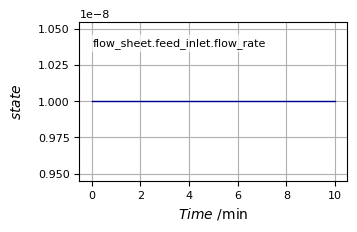

In [13]:
from CADETProcess.instruments import Breakthrough

bt = Breakthrough(
    "bt", fs,
    c_sample=[20.0, 1.0],
    flow_rate=Q,
    cycle_time=600.0,
)
print("feed flow rate:", bt.flow_sheet.feed_inlet.flow_rate[0], "m³/s")
bt.plot_events();